# Introduction to Segmentation: Clustering algorithms


One of the basic unsupervised learning approaches is clustering, where the algorithm has to find out which part of the data belongs together in one cluster. 

For segmentation, this data is taken from the pixel values, possible from a neighborhood of the pixels and often by calculating specific features in this region. However, for the moment we will use the raw (color) data of the pixels and possibly also the location and look at features later.

In [2]:
import numpy as np
import skimage
import skimage.data
import skimage.io
import skimage.future
import skimage.segmentation
import sklearn.cluster
import cv2

# for displaying images in jupyter
from matplotlib import pyplot as plt

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 10]
#mpl.rcParams['figure.dpi']= 400

## Exercise 1: Using KMeans for background subtraction on a medical image

In the first exercise, we want to extract the background from an image showning the hands on green background.

<img src=hand_small.png width=400px>

This could also be achieved by defining a suitable range of color for either the background or the foreground and use thresholding. We want to find out, if it is also possible using k-Means.

Use kmeans for clustering all the pixels in the image into 2 clusters using only the RGB values.

If we use the raw pixels, the position of the pixels do not matter. You will have to reshape the image into a 1D Array of RGB values and convert them to float to be able to use the library function.

There are different implementations of kmeans available, most noteworthy an opencv and a sklearn implementation. We will use the sklearn implementation:

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html


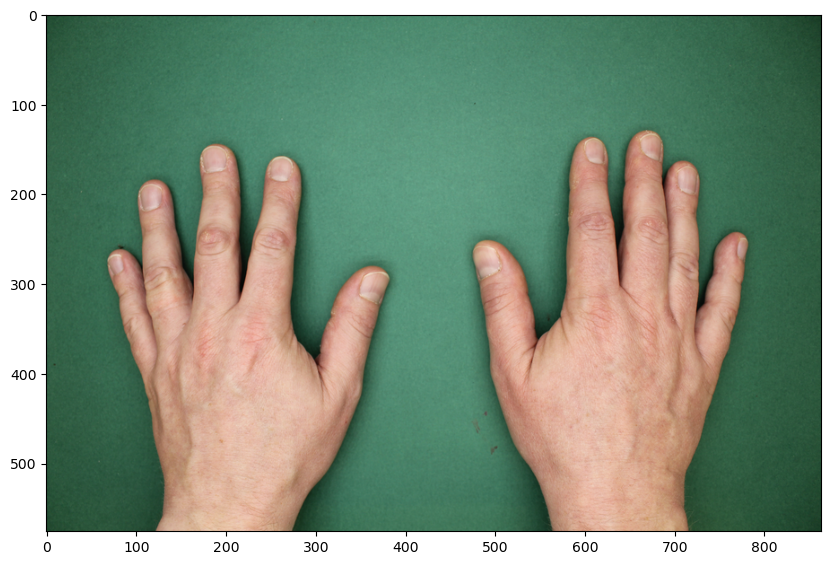

In [36]:
image  = skimage.io.imread('/exchange/cvai/images/hand_small.png')
plt.imshow(image)

### k-Means
Use k-means to find 2 clusters and display them.

For displaying you can use either the found cluster centers as colors or overlay the labels, see https://scikit-image.org/docs/dev/api/skimage.color.html#skimage.color.label2rgb

576 864
(497664, 3)
Image shape:  (576, 864, 3)
Labels shape:  (576, 864)


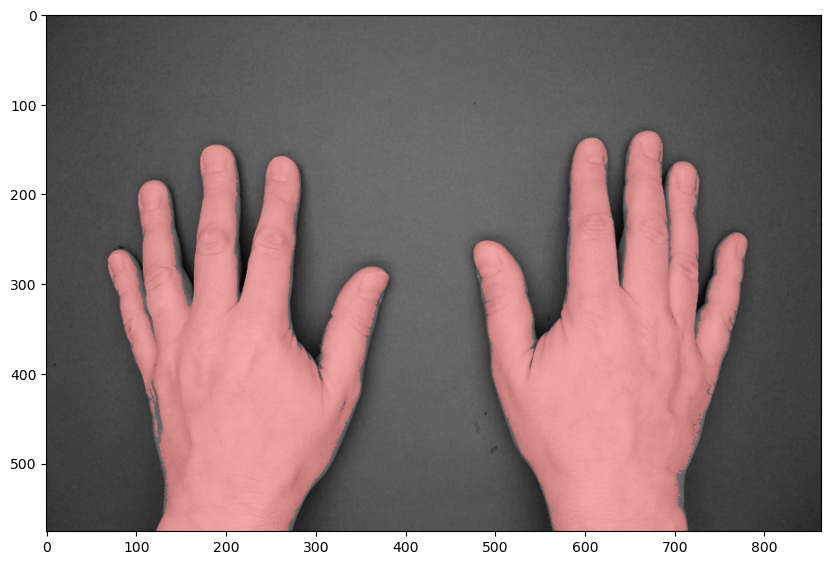

In [37]:
from sklearn.cluster import KMeans
# The first step should be to generate a 1D array of type float32 of the data
# YOUR CODE HERE
height, width, channels = image.shape
print(height, width)

# Farbmerkmale in eine 2D-Form bringen: (n_pixels, n_channels)
color_features = image.reshape((-1, channels))

# Räumliche Koordinaten generieren
x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))
spatial_features = np.stack((x_coords.flatten(), y_coords.flatten()), axis=1)

#lediglich farb features nehmen
data = np.concatenate([color_features], axis=1).astype(np.float32)
# mit zusätzlichen spacial features scheint die korrekte Segmentierung nicht zu funktionieren
#data = np.concatenate([color_features], axis=1).astype(np.float32)

print(data.shape)  # Ausgabe: (Anzahl Pixel, n_channels + 2)

# then create a kmeans object and fit the data
kmeans = KMeans(n_clusters=2, random_state=38)

# fit the data
kmeans.fit(data)                 

# you can check the cluster centers from the kmeans object, this should be close to the color 
# of the hand and of the background.
center_colors = np.uint8(kmeans.cluster_centers_)

# try to plot the result s an image again, there are different ways to do this...
labels_2d = kmeans.labels_.reshape((576, 864))

print("Image shape: ", image.shape)
print("Labels shape: ", labels_2d.shape)

final_clustered_image = skimage.color.label2rgb(labels_2d, image, kind='overlay')
plt.imshow(final_clustered_image)

In [38]:
np.testing.assert_array_equal(data.shape, (497664, 3))
np.testing.assert_array_equal(kmeans.cluster_centers_.shape, (2,3))
# reshape the class labels
label_image_test = kmeans.labels_.reshape((image.shape[0], image.shape[1]))
# these two points are clearly on the background and should have the same label
assert label_image_test[100,100] == label_image_test[200,400]
# this point is on a hand and should have a different label
assert label_image_test[100,100] != label_image_test[400, 200]

How can you find out, if the segmentation was good or not? I.e. if you run it twice, which result should you keep?


576 864
(497664, 3)
Image shape:  (576, 864, 3)
Labels shape:  (576, 864)
final clustered image 1:  [[[0.19490196 0.19490196 0.19490196]
  [0.19764706 0.19764706 0.19764706]
  [0.20313725 0.20313725 0.20313725]
  ...
  [0.17019608 0.17019608 0.17019608]
  [0.17019608 0.17019608 0.17019608]
  [0.17294118 0.17294118 0.17294118]]

 [[0.18941176 0.18941176 0.18941176]
  [0.21137255 0.21137255 0.21137255]
  [0.20862745 0.20862745 0.20862745]
  ...
  [0.16745098 0.16745098 0.16745098]
  [0.16745098 0.16745098 0.16745098]
  [0.17294118 0.17294118 0.17294118]]

 [[0.20039216 0.20039216 0.20039216]
  [0.21411765 0.21411765 0.21411765]
  [0.20588235 0.20588235 0.20588235]
  ...
  [0.17843137 0.17843137 0.17843137]
  [0.17019608 0.17019608 0.17019608]
  [0.17019608 0.17019608 0.17019608]]

 ...

 [[0.19764706 0.19764706 0.19764706]
  [0.19764706 0.19764706 0.19764706]
  [0.19490196 0.19490196 0.19490196]
  ...
  [0.16745098 0.16745098 0.16745098]
  [0.17294118 0.17294118 0.17294118]
  [0.17568627

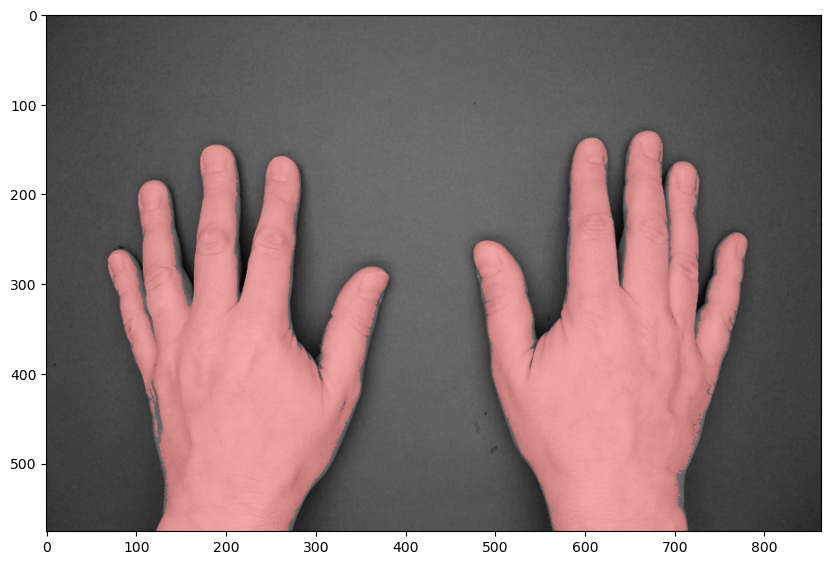

In [39]:
from sklearn.cluster import KMeans
# The first step should be to generate a 1D array of type float32 of the data
# YOUR CODE HERE
height, width, channels = image.shape
print(height, width)

# Farbmerkmale in eine 2D-Form bringen: (n_pixels, n_channels)
color_features = image.reshape((-1, channels))

# Räumliche Koordinaten generieren
x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))
spatial_features = np.stack((x_coords.flatten(), y_coords.flatten()), axis=1)

#lediglich farb features nehmen
data = np.concatenate([color_features], axis=1).astype(np.float32)
# mit zusätzlichen spacial features scheint die korrekte Segmentierung nicht zu funktionieren
#data = np.concatenate([color_features], axis=1).astype(np.float32)

print(data.shape)  # Ausgabe: (Anzahl Pixel, n_channels + 2)

# then create a kmeans object and fit the data
kmeans = KMeans(n_clusters=2, random_state=75)

# fit the data
kmeans.fit(data)                 

# you can check the cluster centers from the kmeans object, this should be close to the color 
# of the hand and of the background.
center_colors = np.uint8(kmeans.cluster_centers_)

# try to plot the result s an image again, there are different ways to do this...
labels_2d = kmeans.labels_.reshape((576, 864))

print("Image shape: ", image.shape)
print("Labels shape: ", labels_2d.shape)

final_clustered_image_2 = skimage.color.label2rgb(labels_2d, image, kind='overlay')

#Potential check if images are slightly different and hopefully almost equal in results
print("final clustered image 1: ", final_clustered_image)
print("final clustered image 2: ", final_clustered_image_2)

plt.imshow(final_clustered_image)

## Exercise 2: K-Means with multiple labels.

Now try the K-Means Algorithmus on the following image to separate the different colored figures and the gray and black background. Ideally we want to have a cluster for every colored figure, one for the table and one for the background, that would be 6 classes.

In [73]:
from sklearn.cluster import KMeans
def detect_tiles(n_cluster_centers, random_state=54):
    image = skimage.io.imread('/exchange/cvai/images/carcassonne_figures.jpg')
    
    # The first step should be to generate a 1D array of type float32 of the data
    # YOUR CODE HERE
    height, width, channels = image.shape
    print(height, width)
    
    # Farbmerkmale in eine 2D-Form bringen: (n_pixels, n_channels)
    color_features = image.reshape((-1, channels))
    
    # Räumliche Koordinaten generieren
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))
    spatial_features = np.stack((x_coords.flatten(), y_coords.flatten()), axis=1)
    
    #farb features und spatial features nehmen
    data = np.concatenate([color_features], axis=1).astype(np.float32)
    
    print(data.shape)  # Ausgabe: (Anzahl Pixel, n_channels + 2)
    
    # then create a kmeans object and fit the data
    kmeans = KMeans(n_clusters=n_cluster_centers, random_state=random_state)
    
    # fit the data
    kmeans.fit(data)                 
    
    # you can check the cluster centers from the kmeans object, this should be close to the color 
    # of the hand and of the background.
    center_colors = np.uint8(kmeans.cluster_centers_)
    
    # try to plot the result s an image again, there are different ways to do this...
    labels_2d = kmeans.labels_.reshape((height, width))
    
    print("Image shape: ", image.shape)
    print("Labels shape: ", labels_2d.shape)
    
    final_clustered_image = skimage.color.label2rgb(labels_2d, image)
    plt.rcParams['figure.figsize'] = [10, 10]
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Originalbild")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(final_clustered_image)
    title ="Segmentiertes Bild mit Clusterzentren: " + str(n_cluster_centers)
    plt.title(title)
    plt.axis('off')

    plt.show()
    return kmeans


684 912
(623808, 3)
Image shape:  (684, 912, 3)
Labels shape:  (684, 912)


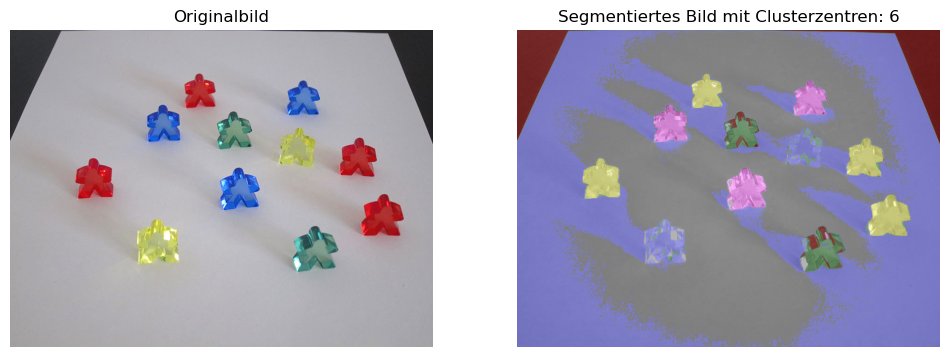

In [74]:
kmeans = detect_tiles(6)

In [75]:
# results depend a bit on the initial conditions of the center, so we dont do any real checks here
assert kmeans is not None
assert kmeans.cluster_centers_.shape[0] == 6

Using 6 classes probably did not generate a very good result. Try different values for the number of clusters. What results do you get? What is the best parameter setting.

684 912
(623808, 3)
Image shape:  (684, 912, 3)
Labels shape:  (684, 912)


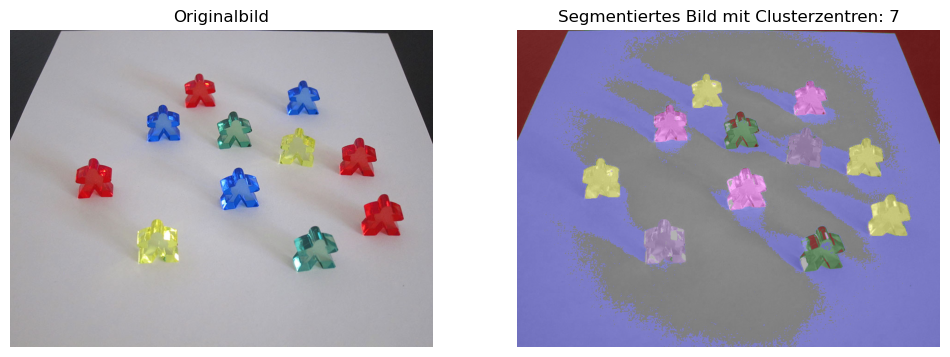

684 912
(623808, 3)
Image shape:  (684, 912, 3)
Labels shape:  (684, 912)


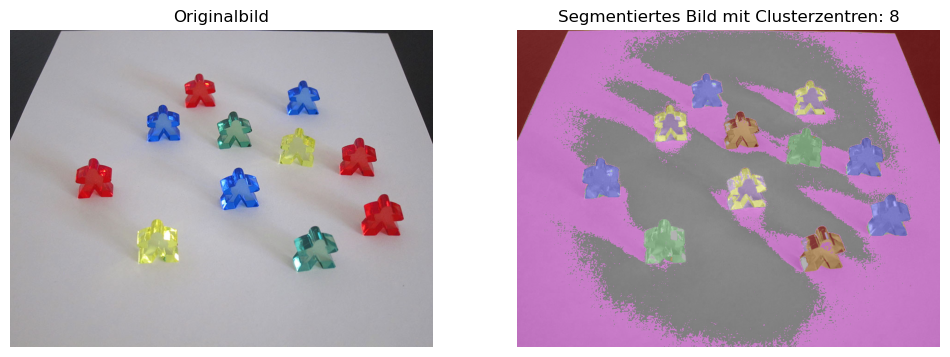

684 912
(623808, 3)
Image shape:  (684, 912, 3)
Labels shape:  (684, 912)


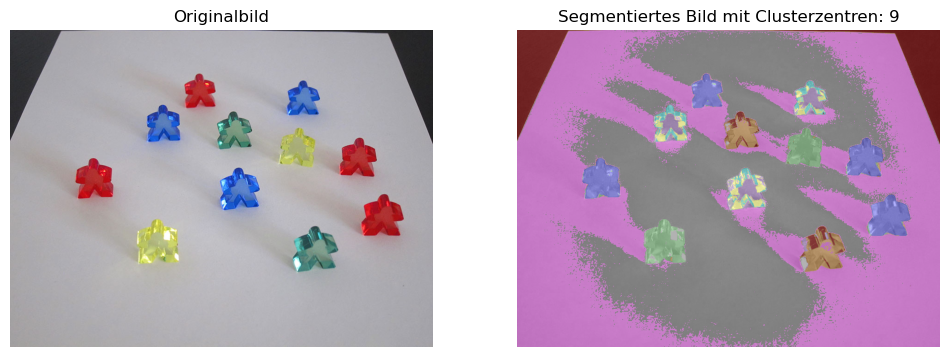

684 912
(623808, 3)
Image shape:  (684, 912, 3)
Labels shape:  (684, 912)


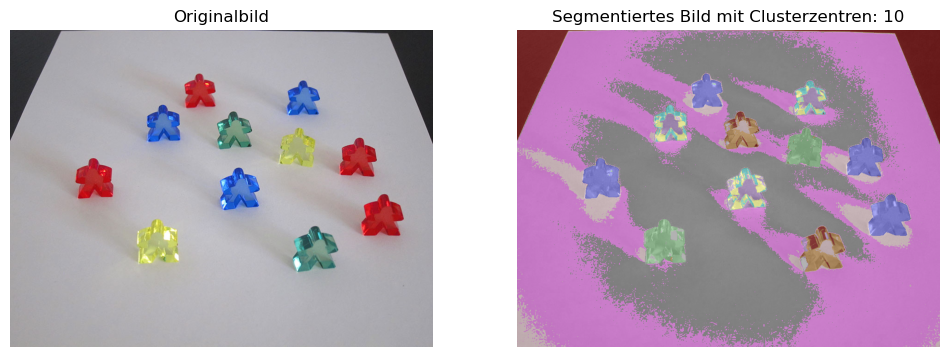

In [76]:
for i in range(7,11):
    detect_tiles(i)

## Exercise 3: Using different color spaces

One of the problems is that similar colors with different intensity will end up in different clusters. How could you solve that issue?

One idea would be to use a color space that has the luminance (or value) as a seperate channel, and then only use the other 2 channels. A possible color space is Lab, but you could also try different ones. You will find color space transfer routines in skimage.color.

Convert the image into another color space and display the 3 channels as gray value image.

(np.float64(-0.5), np.float64(911.5), np.float64(683.5), np.float64(-0.5))

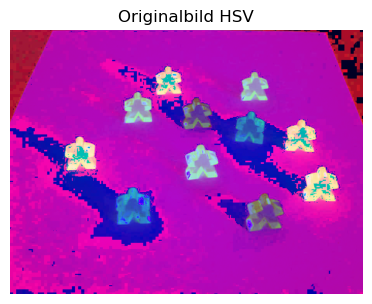

In [86]:
# YOUR CODE HERE
image_hsv = skimage.color.convert_colorspace(image, 'RGB', 'HSV')

plt.subplot(1, 2, 1)
plt.imshow(image_hsv, cmap='gray')
plt.title("Originalbild HSV")
plt.axis('off')



Now we want to drop one of the color spaces and reshape the data so that we have an array of 2 channels instead of 3. Save this data in the variable `data`

In [91]:
data = None
# YOUR CODE HERE
hs = image_hsv[:, :, :2]
_,_,channels = hs.shape
data = hs.reshape(-1, channels)
print(data.shape)

(623808, 2)


In [92]:
np.testing.assert_array_equal(data.shape, (623808, 2))

One of the advantages of 2D data is that we can plot it direclty:

np.float64(1.0)

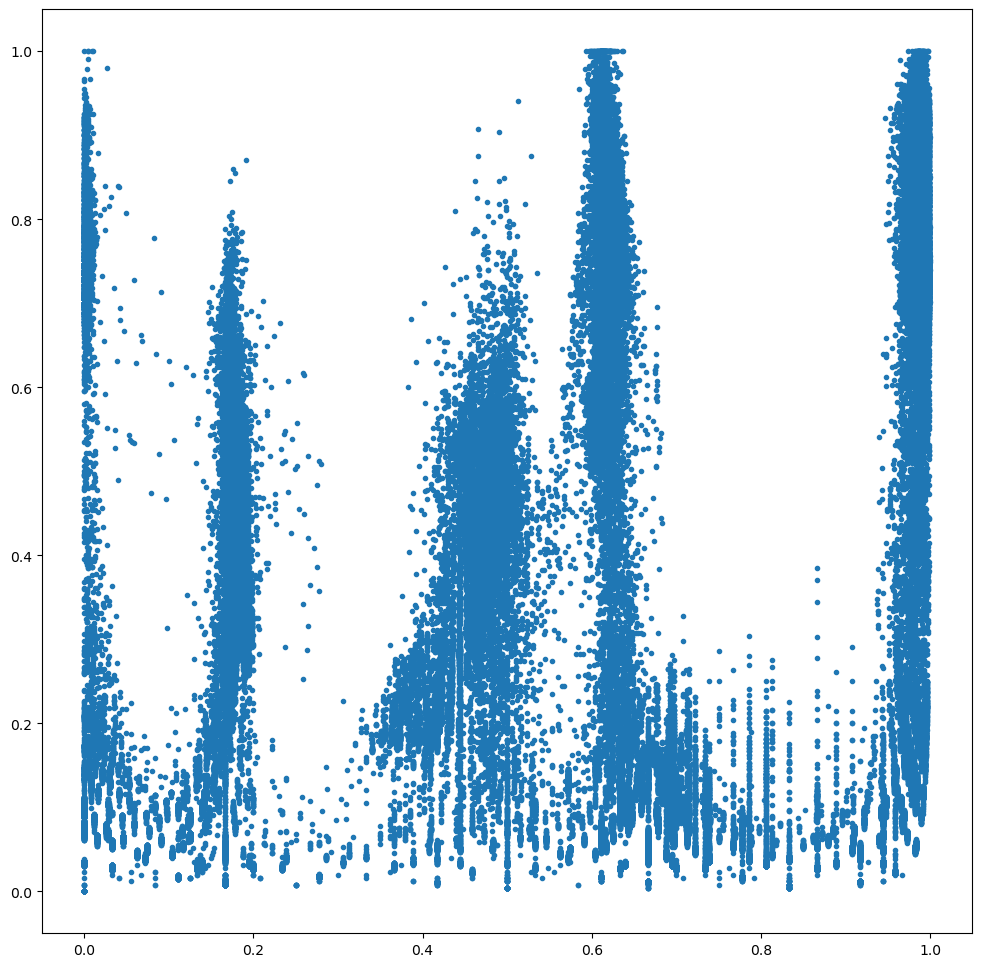

In [93]:
plt.rcParams['figure.figsize'] = [12, 12]
plt.plot(data[:,0], data[:,1], '.')
np.max(data[:,0])
np.max(data[:,1])

Now try to cluster this data into 5 clusters (as background and table are both grey, respectively black). Does it work better?


Image shape:  (684, 912, 3)
Labels shape:  (684, 912)


(np.float64(-0.5), np.float64(911.5), np.float64(683.5), np.float64(-0.5))

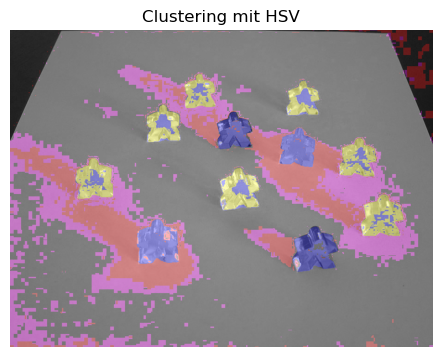

In [102]:
# YOUR CODE HERE
from sklearn.cluster import KMeans
n_cluster_centers=5
random_state = 54
kmeans = KMeans(n_clusters=n_cluster_centers, random_state=random_state)
    
# fit the data
kmeans.fit(data)                 

# you can check the cluster centers from the kmeans object, this should be close to the color 
# of the hand and of the background.
center_colors = np.uint8(kmeans.cluster_centers_)

# try to plot the result s an image again, there are different ways to do this...
labels_2d = kmeans.labels_.reshape((height, width))

print("Image shape: ", image.shape)
print("Labels shape: ", labels_2d.shape)

final_clustered_image_hsv = skimage.color.label2rgb(labels_2d, image)
plt.rcParams['figure.figsize'] = [10, 10]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(final_clustered_image_hsv, cmap='gray')
plt.title("Clustering mit HSV")
plt.axis('off')

We can also display the clustering the feature space.

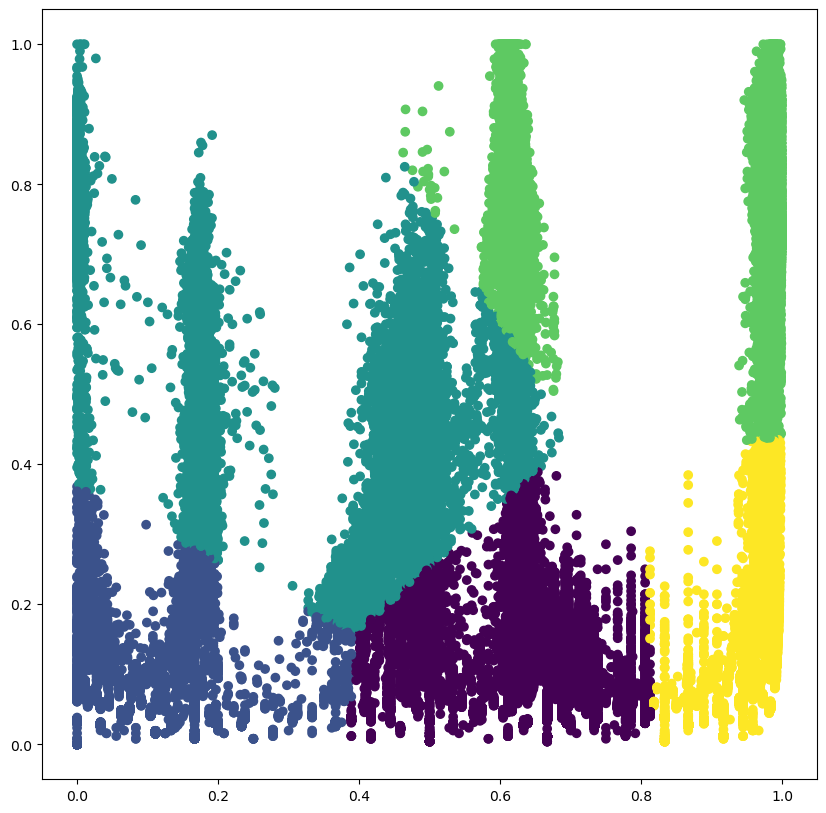

In [100]:
plt.scatter(x=data[:,0], y=data[:,1], c=kmeans.labels_)

## Exercise 4 (optional): k-Means with position and color

Implement a k-Means clustering that uses the position of a pixel together with the color for clustering, does this work better?


## Exercise 5: Mean Shift

As the last exercise, we would like to solve the same clustering using mean shift. There is an implementation in sklearn:

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MeanShift.html

Mean shift is quite a slow algorithm, so we will try with a reduced size image first.


(342, 456, 3)
(155952, 3)


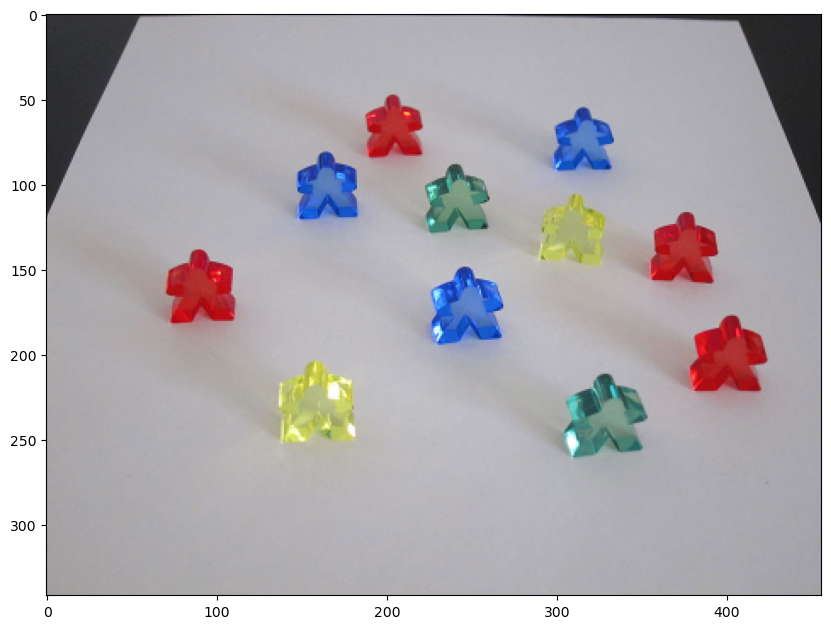

In [9]:
image = skimage.io.imread('/exchange/cvai/images/carcassonne_figures.jpg')
# this reduces the image size by an integer factor using the mean of the neighborhood
image_small = skimage.transform.downscale_local_mean(image, factors=(2,2,1)).astype(int)
data = image_small.reshape((-1,3)).astype(np.float32)
print(image_small.shape)
print(data.shape)
plt.imshow(image_small)


The mean shift algorithms will first evaluate the kernel to be used. This can be done seperately to have more control over values.

In [5]:
bandwidth = sklearn.cluster.estimate_bandwidth(data, quantile=0.2, n_samples=5000)
print(bandwidth)

30.34243433426039


Now create a meanshift object, fit the data and display the result again.

In [11]:
ms = None
# create sklearn.cluster.MeanShift object, fit the data and display the result
# YOUR CODE HERE
ms = sklearn.cluster.MeanShift(bandwidth=bandwidth)
labels = ms.fit_predict(data)
print(labels.shape)
labels_2d_mean_shift = labels.reshape((342, 456))
final_clustered_image_mean_shift = skimage.color.label2rgb(labels_2d_mean_shift, image_small, kind='overlay')

(155952,)


In [12]:
assert ms.cluster_centers_.shape[0] > 10

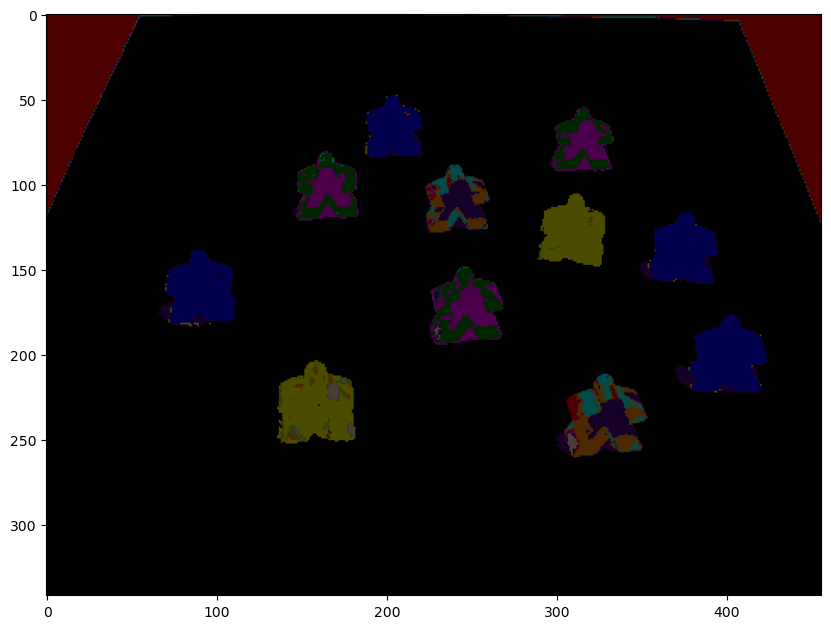

In [13]:
# Spezielle Farben sind wegen der overlay der Labels über das Bild.
plt.imshow(final_clustered_image_mean_shift)

This is all for the exercise.

If you feel like implementing more, how about programming a region growing algorithm :-).